In [1]:
from pathlib import Path
from dataclasses import dataclass
from scipy.stats import chi2
from datetime import datetime, timedelta
from typing import *

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np


ROOT_DIR = Path(os.getcwd()).parent

<h4>Rewriting the code using more efficient Polars</h4>

In [2]:
@dataclass
class PumpEvent:
    ticker: str
    pump_time: str

    def __post_init__(self):
        self.pump_time = datetime.strptime(self.pump_time, "%Y-%m-%d %H:%M:%S")

pump = PumpEvent(ticker="EVXBTC", pump_time="2021-05-02 17:00:07")

In [3]:
def create_date_range(start: datetime, end: datetime) -> List[str]:
    """Creates a range of months and years between two dates"""
    start_year = start.year
    start_month = start.month
    end_year = end.year
    end_month = end.month

    date_range = []

    for year in range(start_year, end_year + 1):
        start_month_range = start_month if year == start_year else 1
        end_month_range = end_month if year == end_year else 12

        for month in range(start_month_range, end_month_range + 1):
            date_range.append(datetime(year=year, month=month, day=1))

    return date_range

In [4]:
def load_data(pump_event: PumpEvent, lookback_delta: timedelta) -> pl.DataFrame:
    rb = pump_event.pump_time
    lb = rb - lookback_delta

    ts_range = create_date_range(start=lb, end=rb)

    TICKER_DIR = os.path.join(ROOT_DIR, "data/trades", pump_event.ticker)
    df = pl.DataFrame()

    for date in ts_range:
        month, year = str(date.month).zfill(2), date.year
        slug = f"{pump_event.ticker}-{year}-{str(month).zfill(2)}.parquet"
        df_tmp = pl.read_parquet(os.path.join(TICKER_DIR, slug))

        df = df.vstack(df_tmp)

    return df

In [5]:
df = load_data(pump_event=pump, lookback_delta=timedelta(days=60))

In [6]:
df = df.with_columns(
    ((1 - 2 * pl.col("isBuyerMaker").cast(pl.Int8)) * pl.col("qty")).alias("qty_sign")
)
df.head()

trade_id,price,qty,time,isBuyerMaker,qty_sign
i64,f64,f64,datetime[ns],bool,f64
9182713,0.000011,38.0,2021-03-01 00:10:36.189,true,-38.0
9182714,0.000011,20.0,2021-03-01 00:10:36.777,true,-20.0
9182715,0.000011,10.0,2021-03-01 00:16:07.992,true,-10.0
9182716,0.000011,23.0,2021-03-01 00:18:56.244,true,-23.0
9182717,0.000011,15.0,2021-03-01 00:18:56.244,true,-15.0


In [7]:
df_group = df.group_by("time", maintain_order=True).agg(
    # Price aggregation
    price_first=pl.col("price").first(),
    price_last=pl.col("price").last(),
    price_min=pl.col("price").min(),
    price_max=pl.col("price").max(),
    price_mean=pl.col("price").mean(),
    # isBuyerMaker Aggregation
    isBuyerMaker=pl.col("isBuyerMaker").mean(),
    qty_abs=pl.col("qty").sum(),
    qty_sign=pl.col("qty_sign").sum(),
)

df_group = df_group.with_columns(
    time=pl.col("time").set_sorted()
)

df_group.shape

(352485, 9)

In [8]:
df_group["isBuyerMaker"].value_counts().sort(by="isBuyerMaker")

isBuyerMaker,count
f64,u32
0.0,190896
0.004274,1
0.00625,1
0.006667,1
0.011111,1
0.011364,1
0.011494,1
0.0125,1
0.013158,1


In [9]:
df_group["time"].max(), df_group["time"].min()

(datetime.datetime(2021, 5, 31, 23, 58, 11, 972000),
 datetime.datetime(2021, 3, 1, 0, 10, 36, 189000))

<h4>Whale features</h4>

<h4>Whale Imbalance</h4>

In [10]:
df_group = df_group.with_columns(
    date = pl.col("time").dt.truncate("1d")
)

df_group.head(1)

time,price_first,price_last,price_min,price_max,price_mean,isBuyerMaker,qty_abs,qty_sign,date
datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,datetime[ns]
2021-03-01 00:10:36.189,0.000011,0.000011,0.000011,0.000011,0.000011,1.0,38.0,-38.0,2021-03-01 00:00:00


In [11]:
df_quantiles = (
    df_group
    .group_by_dynamic(index_column="time", every="1d")
    .agg(quantile=pl.col("qty_abs").quantile(.999))
)

df_group = df_group.join(df_quantiles, left_on="date", right_on="time", how="left")

In [12]:
window = "7d"

df_group = df_group.with_columns(
    is_whale = pl.col("qty_abs") >= pl.col("quantile"),
    is_buy = pl.col("qty_sign") > 0
)

In [13]:
df_group = df_group.with_columns(
    whale_imbalance_ratio=(
        (pl.col("qty_sign") * pl.col("is_whale")).rolling_sum(
            by="time", window_size=window
        )
        / (pl.col("qty_abs") * pl.col("is_whale")).rolling_sum(
            by="time", window_size=window
        )
    ),
    regular_imbalance_ratio=(
        (pl.col("qty_sign") * (1 - pl.col("is_whale"))).rolling_sum(
            by="time", window_size=window
        )
        / (pl.col("qty_abs") * (1 - pl.col("is_whale"))).rolling_sum(
            by="time", window_size=window
        )
    ),
)

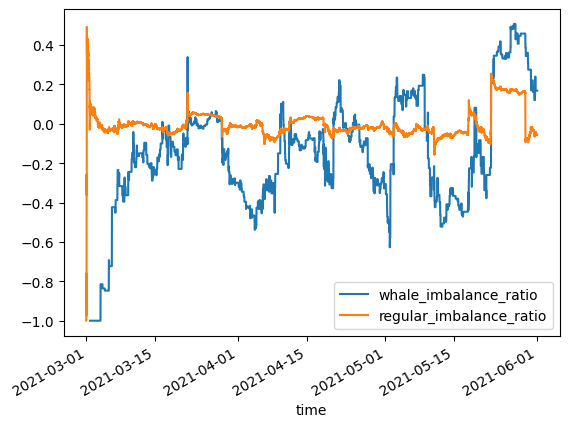

In [14]:
df_group.to_pandas().plot(x="time", y=["whale_imbalance_ratio", "regular_imbalance_ratio"])
plt.show()

<h4>When do whales buy?</h4>

<h4>

In [ ]:
df_group = df_group.with_columns(
    weekday = pl.col("time").dt.weekday()
)

df_group.head(1)

In [ ]:
# prepend dummies dataframe to the right
weekday_dummmies = df_group["weekday"].to_dummies()
weekday_cols = weekday_dummmies.columns

df_group = df_group.with_columns_seq(weekday_dummmies)

df_group = df_group.with_columns(
    whale_vol=(pl.col("is_whale") * pl.col("qty_abs")).rolling_sum(
        by="time", window_size=window
    ),
    whale_num_trade=pl.col("is_whale").cast(pl.Float32).rolling_sum(by="time", window_size=window),
)

df_group = df_group.with_columns_seq(
    df_group.rolling(index_column="time", period=window).agg([
        # weekday_dummy * is_whale * qty_abs
        (pl.col(col) * pl.col("is_whale") * pl.col("qty_abs")).sum()
        for col in weekday_cols
    ])
)

In [ ]:
df_group = df_group.with_columns_seq(
    [pl.col(f"weekday_{i}") / pl.col("whale_vol") for i in range(1, 8)]
)

In [ ]:
df_group.to_pandas()[weekday_cols].round(6).plot.area()
plt.show()

<h4>Trading volume by hours</h4>

In [ ]:
df_group = df_group.with_columns(
    hour=pl.col("time").dt.hour()
)
# Bins hours
bin_hours = [3, 6, 9, 12, 15, 18, 21]
labels=["0-3", "3-6", "6-9", "9-12", "12-15", "15-18", "18-21", "21-24"]
# Create bins for hours
df_group = df_group.with_columns(
    hour_bin = pl.col("hour").cut(breaks=bin_hours, labels=labels, left_closed=True)
)

In [ ]:
# Create dummies for hour bin of the trades
hour_bins_dummies = df_group["hour_bin"].to_dummies()
hour_bins_cols = hour_bins_dummies.columns

df_group = df_group.with_columns_seq(
    hour_bins_dummies
)

# calculate hour bin whale volume
df_group = df_group.with_columns_seq(
    df_group.rolling(index_column="time", period=window).agg(
        [
            # hour_bin_dummy * is_whale * qty_abs
            (pl.col(col) * pl.col("is_whale") * pl.col("qty_abs")).sum()
            for col in hour_bins_cols
        ]
    )
)

# divide by the overall traded volume
df_group = df_group.with_columns_seq(
    [pl.col(col) / pl.col("whale_vol") for col in hour_bins_cols]
)

In [ ]:
df_group[hour_bins_cols].to_pandas().round(6).plot.area()
plt.show()

<h4>Calculate Benford's law chi squared stat</h4>

In [ ]:
df_group = df_group.with_columns(
    qty_first_digit = pl.col("qty_abs").cast(str).str.slice(0,1).cast(pl.Int8)
)

# Similarily create dummies for each first digit
df_group["qty_first_digit"].to_pandas().hist(bins=10)

In [ ]:
df_group = df_group.filter(
    pl.col("qty_first_digit") > 0
)

In [ ]:
df_group = df_group.filter(
    pl.col("qty_first_digit") != 8
)

In [ ]:
first_digits_dummies = df_group["qty_first_digit"].to_dummies()
first_digit_cols = [f"qty_first_digit_{i}" for i in range(1, 10)]

missing_digits = set(range(1, 10)) - set([int(el.split("_")[-1]) for el in first_digits_dummies.columns])

# missing_digits
df_group = df_group.with_columns_seq(first_digits_dummies)

df_group = df_group.with_columns_seq(
    *[
        pl.lit(0).alias(f"qty_first_digit_{col}") for col in missing_digits
    ]
)

df_group = df_group.with_columns_seq(
    df_group.rolling(index_column="time", period=window).agg(
        [
            (pl.col(col) * pl.col("is_whale")).sum()
            for col in first_digit_cols
        ]
    ),
)

In [ ]:
df_group.filter(pl.col("is_whale"))[["qty_first_digit"] + first_digit_cols].head(10)

In [ ]:
# logarithmic distribution Benford's law
expected_freq = pl.Series([np.log(i + 1) - np.log(i) for i in range(1, 10)])
expected_freq

In [ ]:
from scipy.stats import chi2

In [ ]:
# add expected frequencies
df_group = df_group.with_columns(*[
    # expected frequency = distrib * whale_num_trades so far
    (expected_freq[i] * pl.col("whale_num_trade")).alias(f"expected_freq_digit_{i+1}") 
    for i, col in enumerate(first_digit_cols)
])

expected_freq_cols = [
    f"expected_freq_digit_{i}" for i in range(1, 10)
]

# calculate chi_squared statistic
df_group = df_group.with_columns(
    chi2_stat = (
        (df_group[first_digit_cols] - df_group[expected_freq_cols]) / df_group[expected_freq_cols]
    ).sum_horizontal().pow(2)
)

In [ ]:
features = [
    "time", "whale_imbalance_ratio", "regular_imbalance_ratio", "chi2_stat"
] + hour_bins_cols + weekday_cols

df_features = df_group[features]
df_features.tail(2)

In [ ]:
df_group[["time", "chi2_stat"]].to_pandas().plot(x="time", y="chi2_stat")
plt.show()

In [ ]:
df_features.to_pandas()[hour_bins_cols].round(6).plot.area()

In [ ]:
df_features = df_features.rolling(index_column="time", period="1d").agg(
    whale_imbalance_ratio_mean=pl.col("whale_imbalance_ratio").mean(),
    regular_imbalance_ratio_mean=pl.col("regular_imbalance_ratio").mean(),
    # Weekday cols, median - max
    * [pl.col(col).median().alias(f"{col}_median") for col in weekday_cols],
    *[pl.col(col).max().alias(f"{col}_max") for col in weekday_cols],
    # Hours cols, median - max,
    *[pl.col(col).median().alias(f"{col}_median") for col in hour_bins_cols],
    *[pl.col(col).max().alias(f"{col}_max") for col in hour_bins_cols],
    # Pvalue
    *[
        pl.col("chi2_stat").median().alias("chi2_stat_median"),
        pl.col("chi2_stat").max().alias("chi2_stat_max"),
    ],
)

In [ ]:
# select 24*14 hours before

df_res = pl.DataFrame()

for i in range(1, 24*14 + 1):
    after_threshold = df_features["time"] >= pump.pump_time - timedelta(minutes=15) - timedelta(hours=i)

    df_res = pl.concat([
        df_res, df_features.filter(after_threshold)[0]
    ])

df_res = df_res.to_pandas()

In [ ]:
df_res.index = [f"H_{i}" for i in range(1, 24*14+1)]
df_res = df_res.unstack().to_frame().sort_index(level=1).T
df_res.columns = df_res.columns.map("_".join)
df_res

<h4>Lazy API</h4>

In [ ]:
def load_lazy_data(pump_event: PumpEvent, lookback_delta: timedelta) -> pl.LazyFrame:
    rb = pump_event.pump_time
    lb = rb - lookback_delta

    ts_range = create_date_range(start=lb, end=rb)

    TICKER_DIR = os.path.join(ROOT_DIR, "data/trades", pump_event.ticker)

    dfs = []

    for date in ts_range:
        month, year = str(date.month).zfill(2), date.year
        slug = f"{pump_event.ticker}-{year}-{str(month).zfill(2)}.parquet"
        df_tmp = pl.scan_parquet(os.path.join(TICKER_DIR, slug))

        dfs.append(df_tmp)

    return pl.concat(dfs, how="vertical")

In [ ]:
df = load_lazy_data(pump_event=pump, lookback_delta=timedelta(days=60))

df_group = (
    df
    .with_columns(
        ((1 - 2 * pl.col("isBuyerMaker").cast(pl.Int8)) * pl.col("qty")).alias("qty_sign")
    )
    .group_by("time", maintain_order=True).agg(
    # Price aggregation
        price_first=pl.col("price").first(),
        price_last=pl.col("price").last(),
        price_min=pl.col("price").min(),
        price_max=pl.col("price").max(),
        qty_abs=pl.col("qty").sum(),
        qty_sign=pl.col("qty_sign").sum(),
    )
    .with_columns(
        time=pl.col("time").set_sorted()
    )
    .with_columns(
        date=pl.col("time").dt.truncate("1d")
    )
)

df_quantiles = (
    df_group
    .group_by_dynamic(
        index_column="time", every="1d"
    )
    .agg(
        qty_quantile=pl.col("qty_abs").quantile(.999)
    )
)

df_group = (
    df_group.join(df_quantiles, left_on="date", right_on="time", how="left")
    .with_columns(
        is_whale = pl.col("qty_abs") >= pl.col("qty_quantile"),
        is_buy = pl.col("qty_sign") > 0
    )
    .with_columns(
        # Whale volumes
        rolling_qty_abs_whale_vol = (pl.col("qty_abs") * pl.col("is_whale")).rolling_sum(by="time", window_size=window),
        rolling_qty_sign_whale_vol = (pl.col("qty_sign") * pl.col("is_whale")).rolling_sum(by="time", window_size=window),
        # Regular volumes
        rolling_qty_abs_reg_vol = (pl.col("qty_abs") * ~pl.col("is_whale")).rolling_sum(by="time", window_size=window),
        rolling_qty_sign_reg_vol = (pl.col("qty_sign") * pl.col("is_whale")).rolling_sum(by="time", window_size=window),
    )
    .with_columns(
        whale_imbalance_ratio = pl.col("rolling_qty_sign_whale_vol") / pl.col("rolling_qty_abs_whale_vol"),
        regular_imbalance_ratio = pl.col("rolling_qty_sign_reg_vol") / pl.col("rolling_qty_abs_reg_vol")
    )
)

In [ ]:
df_group = (
    df_group
    .with_columns(
        weekday = pl.col("time").dt.weekday()
    )
    # prepend dummies dataframe to the right
weekday_dummmies = df_group["weekday"].to_dummies()
weekday_cols = weekday_dummmies.columns

df_group = df_group.with_columns_seq(weekday_dummmies)

df_group = df_group.with_columns(
    whale_vol=(pl.col("is_whale") * pl.col("qty_abs")).rolling_sum(
        by="time", window_size=window
    ),
    whale_num_trade=pl.col("is_whale").cast(pl.Float32).rolling_sum(by="time", window_size=window),
)

df_group = df_group.with_columns_seq(
    df_group.rolling(index_column="time", period=window).agg([
        # weekday_dummy * is_whale * qty_abs
        (pl.col(col) * pl.col("is_whale") * pl.col("qty_abs")).sum()
        for col in weekday_cols
    ])
)
)

df_group.head(1)